In [1]:
import pandas as pd
import numpy as np
import cv2
import os

df = pd.read_csv("/workspace/prep/prep_label.csv", names=["filename", "label"])

X = []
y = []
base_path = "/workspace/prep"

In [2]:
for _, row in df.iterrows():
    filename = row['filename']
    label = row['label']

    img_path = os.path.join(base_path, filename)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (100, 100))
    
    if img is None:
        continue
    X.append(img)
    y.append(label)


In [3]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)
print(y)

(17650, 100, 100, 3)
(17650,)
['normal' 'normal' 'normal' ... 'normal' 'normal' 'abnormal']


I0000 00:00:1773208697.272684    1384 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Dataset Split: 12001 Train, 3001 Validation, 2648 Test
Found 12001 validated image filenames belonging to 2 classes.
Found 3001 validated image filenames belonging to 2 classes.
Found 2648 validated image filenames belonging to 2 classes.


I0000 00:00:1773208700.427922    1384 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21287 MB memory:  -> device: 0, name: Quadro RTX 6000, pci bus id: 0000:05:00.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Starting Training ---
Epoch 1/10


I0000 00:00:1773208706.002410    1384 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1773208713.274784    1740 service.cc:153] XLA service 0x79e58c0343c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773208713.274829    1740 service.cc:161]   StreamExecutor [0]: Quadro RTX 6000, Compute Capability 7.5 (Driver: 12.8.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1773208713.551593    1740 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773208715.653196    1740 cuda_dnn.cc:461] Loaded cuDNN version 91002


  3/376 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.4444 - loss: 0.8425   

I0000 00:00:1773208723.228486    1740 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


376/376 ━━━━━━━━━━━━━━━━━━━━ 72s 145ms/step - accuracy: 0.5730 - loss: 0.6804 - val_accuracy: 0.6281 - val_loss: 0.6446
Epoch 2/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.6954 - loss: 0.6035 - val_accuracy: 0.7484 - val_loss: 0.5891
Epoch 4/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.7078 - loss: 0.5884 - val_accuracy: 0.7441 - val_loss: 0.5772
Epoch 5/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.7207 - loss: 0.5759 - val_accuracy: 0.7111 - val_loss: 0.5815
Epoch 6/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.7299 - loss: 0.5597 - val_accuracy: 0.7607 - val_loss: 0.5497
Epoch 8/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.7369 - loss: 0.5471 - val_accuracy: 0.7504 - val_loss: 0.5380
Epoch 10/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.7644 - loss: 0.5245
Test Accuracy: 76.44%
83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 137ms/step

--- Classification Report ---
              precision    recall  f1-score  

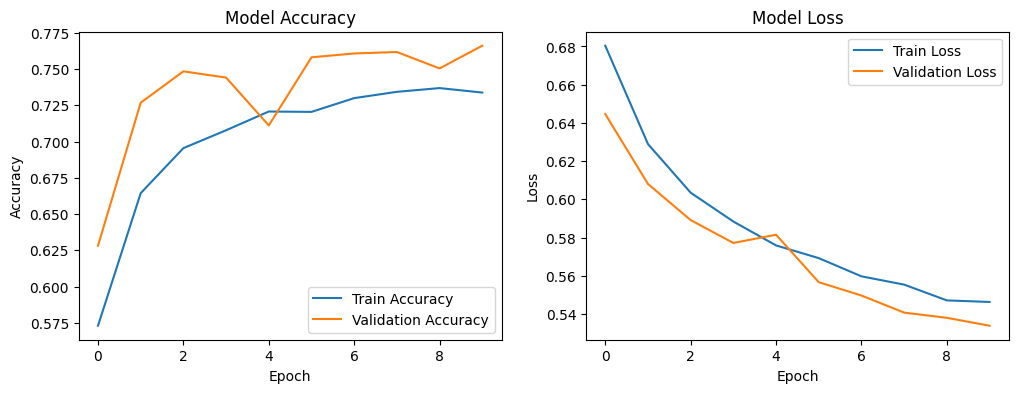

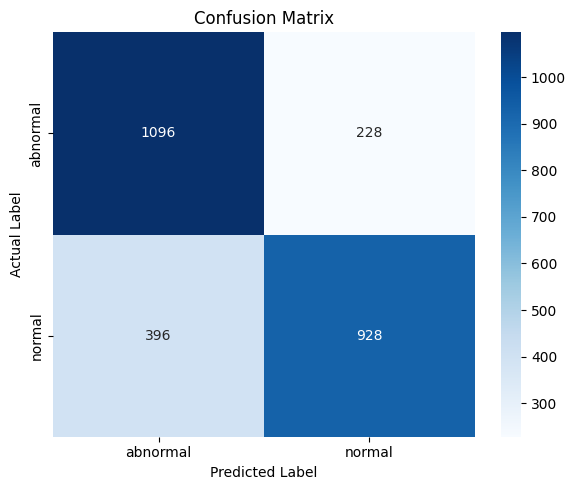

In [4]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Configuration
IMAGE_DIR = "prep"
CSV_FILE = os.path.join(IMAGE_DIR, "prep_label.csv")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# 2. Load the CSV and Split the Data
df = pd.read_csv(CSV_FILE, names=['filename', 'label'])

# First, split off 15% for the final TEST set
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42, stratify=df['label'])

# Next, split the remaining data into TRAIN (80%) and VALIDATION (20%)
train_df, val_df = train_test_split(train_val_df, test_size=0.20, random_state=42, stratify=train_val_df['label'])

print(f"Dataset Split: {len(train_df)} Train, {len(val_df)} Validation, {len(test_df)} Test")

# 3. Data Generators
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df, directory=IMAGE_DIR, x_col="filename", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df, directory=IMAGE_DIR, x_col="filename", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)

# CRITICAL: shuffle=False for the test set so our predictions align with the true labels!
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df, directory=IMAGE_DIR, x_col="filename", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

# 4. Build and Compile Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the Model
print("\n--- Starting Training ---")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

model.save("cell_classifier_model.h5")
print("Model saved as 'cell_classifier_model.h5'")

# 6. Plot Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.savefig('training_curves.png')
print("Saved training curves to 'training_curves.png'")

# 7. Evaluate on the Hold-out Test Set
print("\n--- Running Final Evaluation on Test Set ---")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Get actual predictions
predictions = model.predict(test_generator)
# Convert probabilities (0.0 to 1.0) into binary class predictions (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_generator.classes

# 8. Print Metrics and Confusion Matrix
class_names = list(test_generator.class_indices.keys())

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
print("Saved confusion matrix to 'confusion_matrix.png'")

In [5]:
# Save only the weights
# Note: Keras recommends the '.weights.h5' extension for weights in newer versions
weight_path = "cell_classifier_weights.weights.h5"
model.save_weights(weight_path)
print(f"Model weights successfully exported to '{weight_path}'")

Model weights successfully exported to 'cell_classifier_weights.weights.h5'
